# Variational Autoencoder with PyTorch 

### Torch

In [1]:
pip install torch torchvision

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/203.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/203.1 MB 4.2 MB/s eta 0:00:48
   ---------------------------------------- 1.0/203.1 MB 3.0 MB/s eta 0:01:09
   ---------------------------------------- 1.6/203.1 MB 3.1 MB/s eta 0:01:05
   ---------------------------------------- 1.8/203.1 MB 2.9 MB/s eta 0:01:10
   ---------------------------------------- 2.4/203.1 MB 2.6 MB/s eta 0:01:18
    --------------------------------------- 2.6/203.1 MB 2.3 MB/s eta 0:01:27
    --------------------------------------- 2.9/203.1 MB 2.2 MB/s eta 0:01:30
    ---------------------------


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\BOUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing

# Any results you write to the current directory are saved as output.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Get a quick view of the data 

In [3]:
DATA_PATH = r'C:\Users\BOUKA\Downloads\VAE-Code\inputs\ThoracicSurgery.csv'
df = pd.read_csv(DATA_PATH, sep=',')
df.columns

Index(['id', 'DGN', 'PRE4', 'PRE5', 'PRE6', 'PRE7', 'PRE8', 'PRE9', 'PRE10',
       'PRE11', 'PRE14', 'PRE17', 'PRE19', 'PRE25', 'PRE30', 'PRE32', 'AGE',
       'Risk1Yr'],
      dtype='object')

In [4]:
df.shape

(470, 18)

## Process datasets

### Thoracic dataset

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       470 non-null    int64  
 1   DGN      470 non-null    object 
 2   PRE4     470 non-null    float64
 3   PRE5     470 non-null    float64
 4   PRE6     470 non-null    object 
 5   PRE7     470 non-null    object 
 6   PRE8     470 non-null    object 
 7   PRE9     470 non-null    object 
 8   PRE10    470 non-null    object 
 9   PRE11    470 non-null    object 
 10  PRE14    470 non-null    object 
 11  PRE17    470 non-null    object 
 12  PRE19    470 non-null    object 
 13  PRE25    470 non-null    object 
 14  PRE30    470 non-null    object 
 15  PRE32    470 non-null    object 
 16  AGE      470 non-null    int64  
 17  Risk1Yr  470 non-null    object 
dtypes: float64(2), int64(2), object(14)
memory usage: 66.2+ KB


In [7]:
df.drop("id", axis=1, inplace=True)

In [8]:
df.head()

,DGN,PRE4,PRE5,PRE6,PRE7,PRE8,PRE9,PRE10,PRE11,PRE14,PRE17,PRE19,PRE25,PRE30,PRE32,AGE,Risk1Yr
0,DGN2,2.88,2.16,PRZ1,F,F,F,T,T,OC14,F,F,F,T,F,60,F
1,DGN3,3.40,1.88,PRZ0,F,F,F,F,F,OC12,F,F,F,T,F,51,F
2,DGN3,2.76,2.08,PRZ1,F,F,F,T,F,OC11,F,F,F,T,F,59,F
3,DGN3,3.68,3.04,PRZ0,F,F,F,F,F,OC11,F,F,F,F,F,54,F
4,DGN3,2.44,0.96,PRZ2,F,T,F,T,T,OC11,F,F,F,T,F,73,T


In [9]:
for col in df.columns:
    print(f" {col} unique vals: {df[col].unique()}, anc values count :{ df[col].value_counts()}")

 DGN unique vals: ['DGN2' 'DGN3' 'DGN4' 'DGN8' 'DGN5' 'DGN6' 'DGN1'], anc values count :DGN
DGN3    349
DGN2     52
DGN4     47
DGN5     15
DGN6      4
DGN8      2
DGN1      1
Name: count, dtype: int64
 PRE4 unique vals: [2.88 3.4  2.76 3.68 2.44 2.48 4.36 3.19 3.16 2.32 2.56 4.28 3.   3.98
 1.96 4.68 2.21 2.96 2.6  4.48 3.32 2.36 4.32 4.56 3.24 3.96 4.44 1.81
 2.2  4.2  4.6  3.8  3.2  2.68 3.56 4.16 2.64 2.52 4.   3.76 3.28 3.72
 5.12 3.84 3.52 3.04 4.96 3.15 2.72 3.08 3.48 3.6  6.3  1.84 2.84 4.9
 2.83 6.08 1.88 2.63 3.36 2.35 4.95 4.52 2.8  3.3  2.   3.31 5.6  2.12
 2.5  4.84 2.92 2.08 2.16 5.17 3.64 3.92 3.88 3.44 3.12 2.4  2.57 2.28
 4.04 1.44 5.08 4.92 2.73 2.98 4.08 2.24 4.72 3.58 2.22 2.66 2.87 4.24
 4.8  4.76 2.46 5.52 4.88 5.49 5.56 3.81 2.07 1.7  4.57 4.12 4.59 5.16
 1.98 2.1  4.65 2.58 5.03 2.94 1.82 3.05 2.04 2.38 4.03 5.   4.4  2.7
 5.36 4.64 1.46 2.81 3.18 3.87 3.67 5.2 ], anc values count :PRE4
2.60    13
2.96    13
3.04    11
2.48    11
3.40    11
        ..
2.87     1

In [10]:
# One hot encoding of categorical variables: ["PRE14", "PRE6", "DGN"]

PRE14_dummies = pd.get_dummies(df['PRE14'], prefix='PRE14', drop_first=True)
PRE6_dummies = pd.get_dummies(df['PRE6'], prefix='PRE6', drop_first=True)
DGN_dummies = pd.get_dummies(df['DGN'], prefix='DGN',drop_first=True)
df.drop(["PRE14", "PRE6", "DGN"], axis=1, inplace=True)
df = pd.concat([df, PRE14_dummies, PRE6_dummies, DGN_dummies], axis=1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PRE4        470 non-null    float64
 1   PRE5        470 non-null    float64
 2   PRE7        470 non-null    object 
 3   PRE8        470 non-null    object 
 4   PRE9        470 non-null    object 
 5   PRE10       470 non-null    object 
 6   PRE11       470 non-null    object 
 7   PRE17       470 non-null    object 
 8   PRE19       470 non-null    object 
 9   PRE25       470 non-null    object 
 10  PRE30       470 non-null    object 
 11  PRE32       470 non-null    object 
 12  AGE         470 non-null    int64  
 13  Risk1Yr     470 non-null    object 
 14  PRE14_OC12  470 non-null    bool   
 15  PRE14_OC13  470 non-null    bool   
 16  PRE14_OC14  470 non-null    bool   
 17  PRE6_PRZ1   470 non-null    bool   
 18  PRE6_PRZ2   470 non-null    bool   
 19  DGN_DGN2    470 non-null    b

In [12]:
# encode categorical variables ['T', 'F'] as [1, 0] and booleans as [True, False]->[1, 0]:
#df['DGN_DGN8'].dtypes
print(f"types of variables before: {df.dtypes}")

mapping_obj = {"F":0, "T":1}
mapping_bool = {True:1, False:0}
for col in df.columns:
    if df[col].dtypes=="O":
        df[col] = df[col].map(mapping_obj)
    if df[col].dtypes=="bool":
        df[col] = df[col].map(mapping_bool)
print(f"types of variables after: {df.dtypes}")


types of variables before: PRE4          float64
PRE5          float64
PRE7           object
PRE8           object
PRE9           object
PRE10          object
PRE11          object
PRE17          object
PRE19          object
PRE25          object
PRE30          object
PRE32          object
AGE             int64
Risk1Yr        object
PRE14_OC12       bool
PRE14_OC13       bool
PRE14_OC14       bool
PRE6_PRZ1        bool
PRE6_PRZ2        bool
DGN_DGN2         bool
DGN_DGN3         bool
DGN_DGN4         bool
DGN_DGN5         bool
DGN_DGN6         bool
DGN_DGN8         bool
dtype: object
types of variables after: PRE4          float64
PRE5          float64
PRE7            int64
PRE8            int64
PRE9            int64
PRE10           int64
PRE11           int64
PRE17           int64
PRE19           int64
PRE25           int64
PRE30           int64
PRE32           int64
AGE             int64
Risk1Yr         int64
PRE14_OC12      int64
PRE14_OC13      int64
PRE14_OC14      int64
PRE6_PRZ1

In [13]:
df.columns

Index(['PRE4', 'PRE5', 'PRE7', 'PRE8', 'PRE9', 'PRE10', 'PRE11', 'PRE17',
       'PRE19', 'PRE25', 'PRE30', 'PRE32', 'AGE', 'Risk1Yr', 'PRE14_OC12',
       'PRE14_OC13', 'PRE14_OC14', 'PRE6_PRZ1', 'PRE6_PRZ2', 'DGN_DGN2',
       'DGN_DGN3', 'DGN_DGN4', 'DGN_DGN5', 'DGN_DGN6', 'DGN_DGN8'],
      dtype='object')

In [14]:
new_order = ['PRE4', 'PRE5', 'PRE7', 'PRE8', 'PRE9', 'PRE10', 'PRE11', 'PRE17',
       'PRE19', 'PRE25', 'PRE30', 'PRE32', 'AGE',  'PRE14_OC12',
       'PRE14_OC13', 'PRE14_OC14', 'PRE6_PRZ1', 'PRE6_PRZ2', 'DGN_DGN2',
       'DGN_DGN3', 'DGN_DGN4', 'DGN_DGN5', 'DGN_DGN6', 'DGN_DGN8', 'Risk1Yr']
df = df[new_order]

#### Null Values

<Axes: >

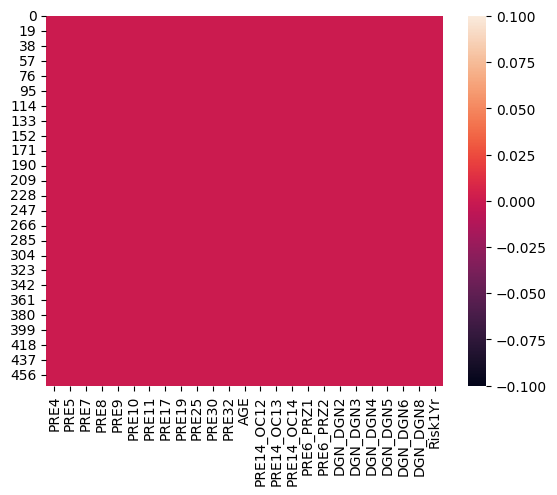

In [15]:
sns.heatmap(df.isnull())

In [16]:
df.isnull().sum()

PRE4          0
PRE5          0
PRE7          0
PRE8          0
PRE9          0
PRE10         0
PRE11         0
PRE17         0
PRE19         0
PRE25         0
PRE30         0
PRE32         0
AGE           0
PRE14_OC12    0
PRE14_OC13    0
PRE14_OC14    0
PRE6_PRZ1     0
PRE6_PRZ2     0
DGN_DGN2      0
DGN_DGN3      0
DGN_DGN4      0
DGN_DGN5      0
DGN_DGN6      0
DGN_DGN8      0
Risk1Yr       0
dtype: int64

In [17]:
df.describe()

,PRE4,PRE5,PRE7,PRE8,PRE9,PRE10,PRE11,PRE17,PRE19,PRE25,...,PRE14_OC14,PRE6_PRZ1,PRE6_PRZ2,DGN_DGN2,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,Risk1Yr
count,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,...,470.000000,470.000000,470.000000,470.000000,470.000000,470.00000,470.000000,470.000000,470.000000,470.000000
mean,3.281638,4.568702,0.065957,0.144681,0.065957,0.687234,0.165957,0.074468,0.004255,0.017021,...,0.036170,0.665957,0.057447,0.110638,0.742553,0.10000,0.031915,0.008511,0.004255,0.148936
std,0.871395,11.767857,0.248472,0.352154,0.248472,0.464114,0.372439,0.262811,0.065163,0.129488,...,0.186912,0.472157,0.232942,0.314018,0.437693,0.30032,0.175961,0.091958,0.065163,0.356405
min,1.440000,0.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2.600000,1.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.160000,2.400000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.807500,3.080000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,6.300000,86.300000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [18]:
df.rename(columns={'Risk1Yr': 'Outcome'}, inplace=True)

In [19]:
df.columns

Index(['PRE4', 'PRE5', 'PRE7', 'PRE8', 'PRE9', 'PRE10', 'PRE11', 'PRE17',
       'PRE19', 'PRE25', 'PRE30', 'PRE32', 'AGE', 'PRE14_OC12', 'PRE14_OC13',
       'PRE14_OC14', 'PRE6_PRZ1', 'PRE6_PRZ2', 'DGN_DGN2', 'DGN_DGN3',
       'DGN_DGN4', 'DGN_DGN5', 'DGN_DGN6', 'DGN_DGN8', 'Outcome'],
      dtype='object')

#### Cleansing the data: removing outliers

* **There are two classes for 1 year survival period -  (T)rue value if died (T,F) ->(1,0)**

### Visualizations

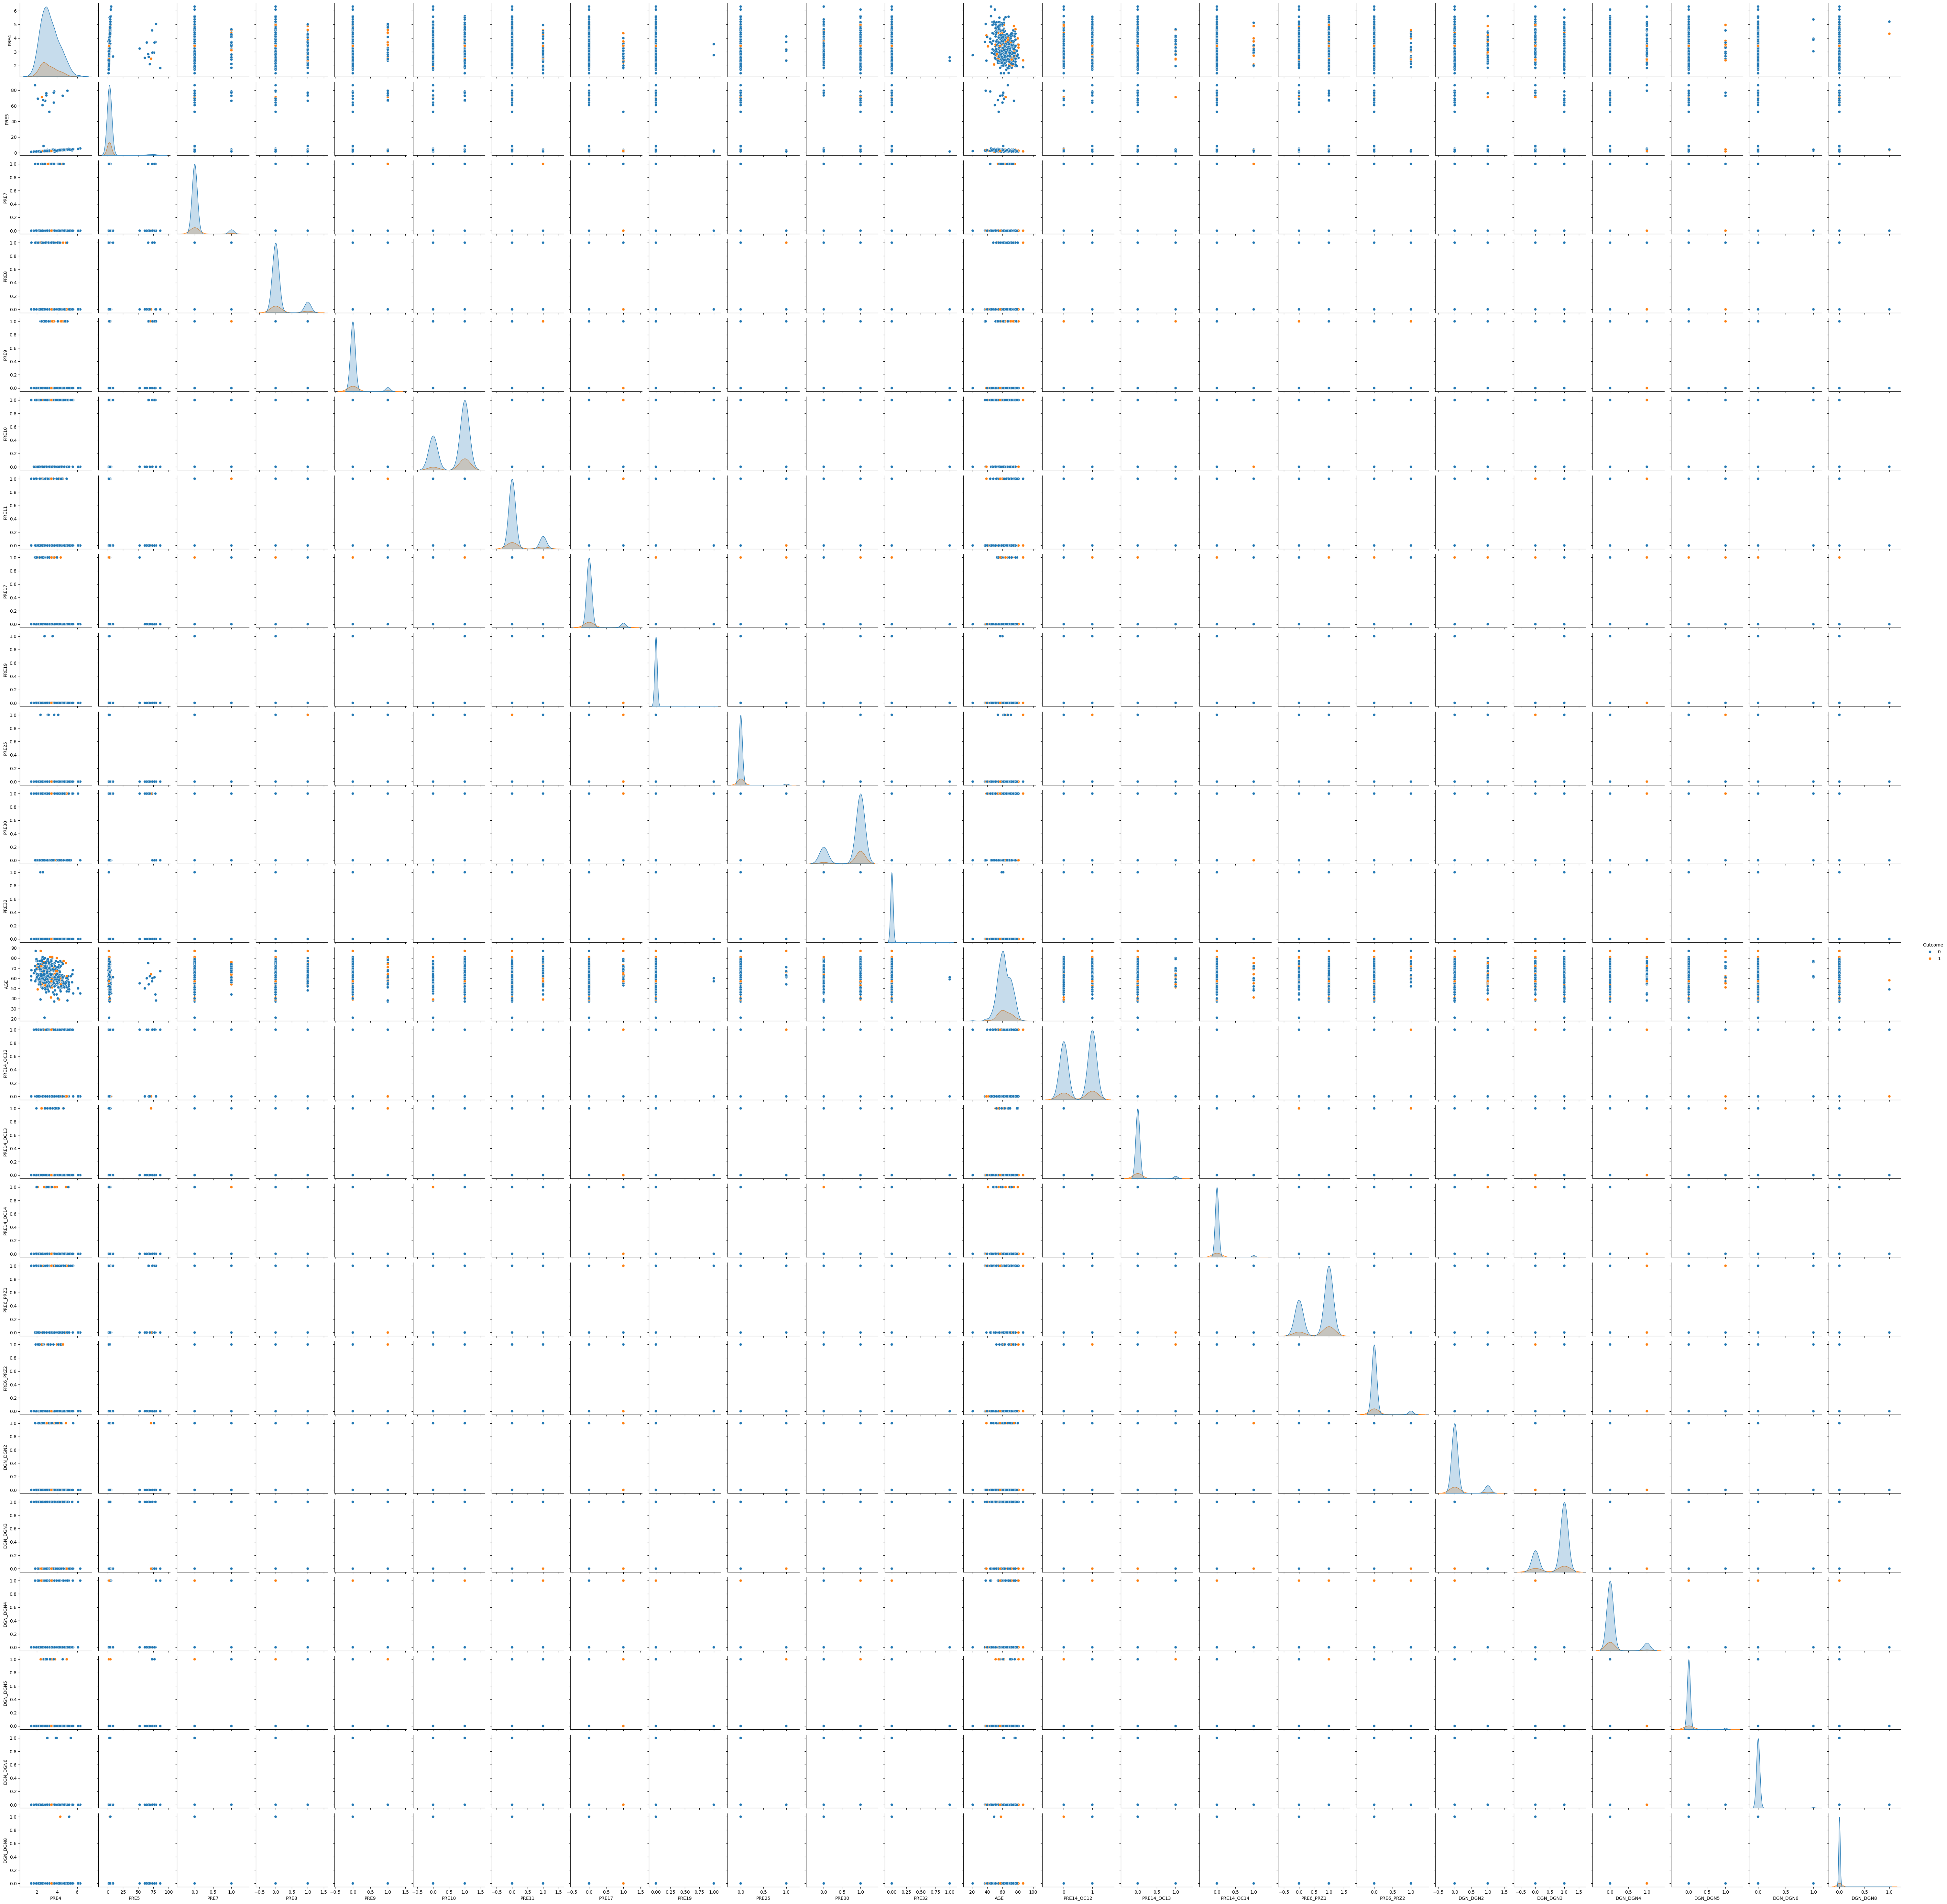

In [38]:
sns.pairplot(data=df, hue='Outcome')

#### Spearman Rank Correlation

<Axes: >

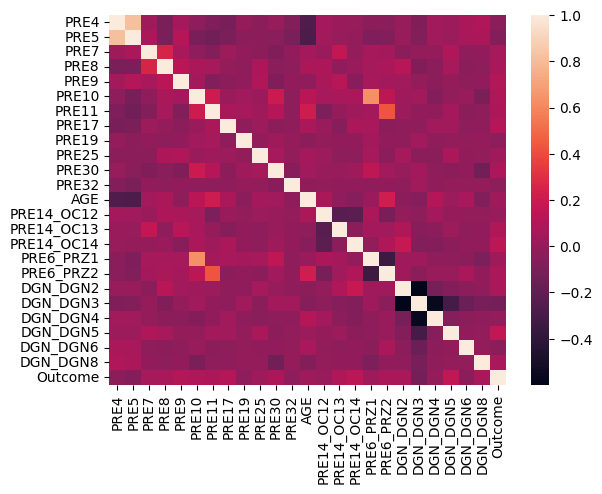

In [20]:
corr = df.corr(method="spearman")
sns.heatmap(corr,annot=False)

* We drop outlier values using **IQR(Interquartile Range Method)**

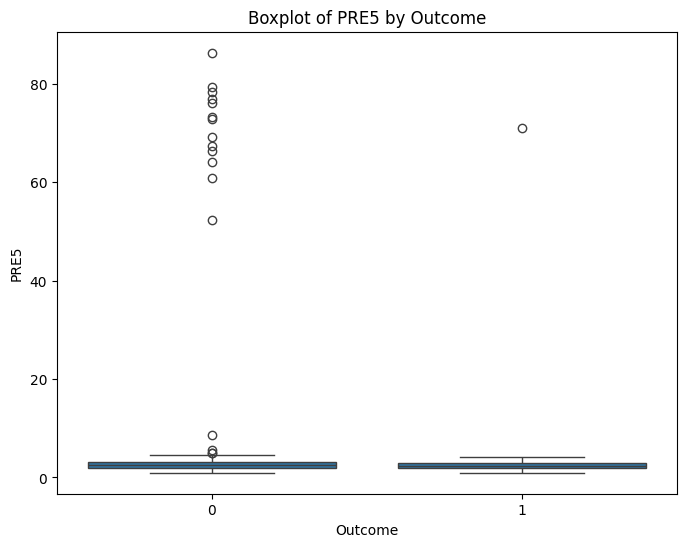

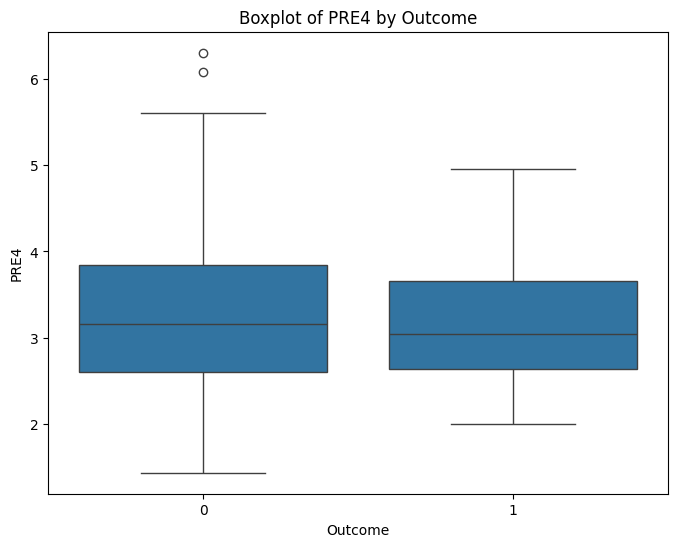

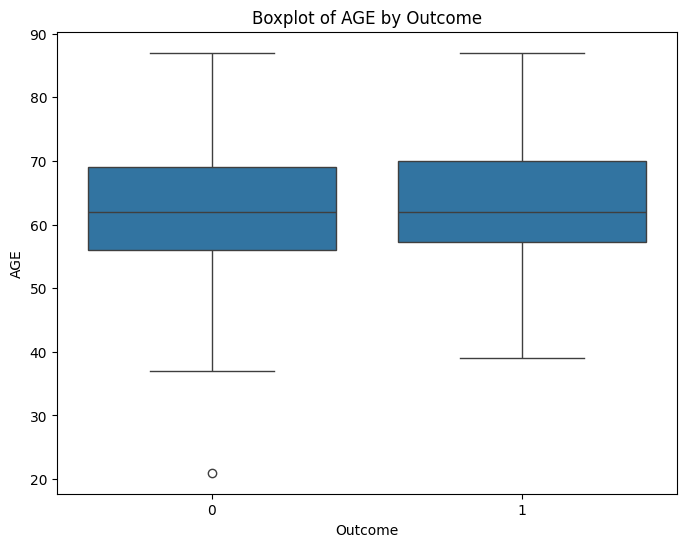

In [21]:
#cols = [col for col in df.columns if col!="Outcome"]
num_cols = ['PRE5', 'PRE4', 'AGE']
for col in num_cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [22]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [23]:
df[num_cols].describe()

,PRE5,PRE4,AGE
count,470.000000,470.000000,470.000000
mean,4.568702,3.281638,62.534043
std,11.767857,0.871395,8.706902
min,0.960000,1.440000,21.000000
25%,1.960000,2.600000,57.000000
50%,2.400000,3.160000,62.000000
75%,3.080000,3.807500,69.000000
max,86.300000,6.300000,87.000000


In [24]:
for col in num_cols:
    lowScore, highScore = removeOutlier(df[col])
    print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
    df[col] = np.where(df[col]>highScore, highScore, df[col])
    df[col] = np.where(df[col]<lowScore, lowScore, df[col])

Column: PRE5, Lower Bound: 0.2799999999999998, Upper Bound: 4.76
Column: PRE4, Lower Bound: 0.7887500000000001, Upper Bound: 5.61875
Column: AGE, Lower Bound: 39.0, Upper Bound: 87.0


* **Check if the outliers are handled**

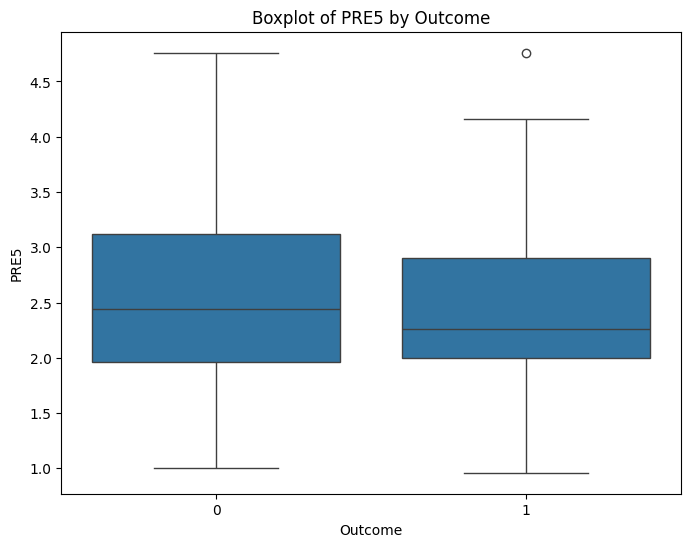

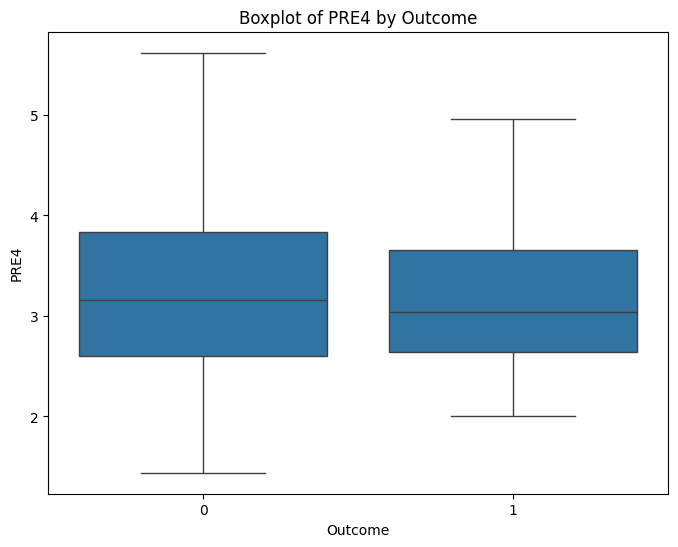

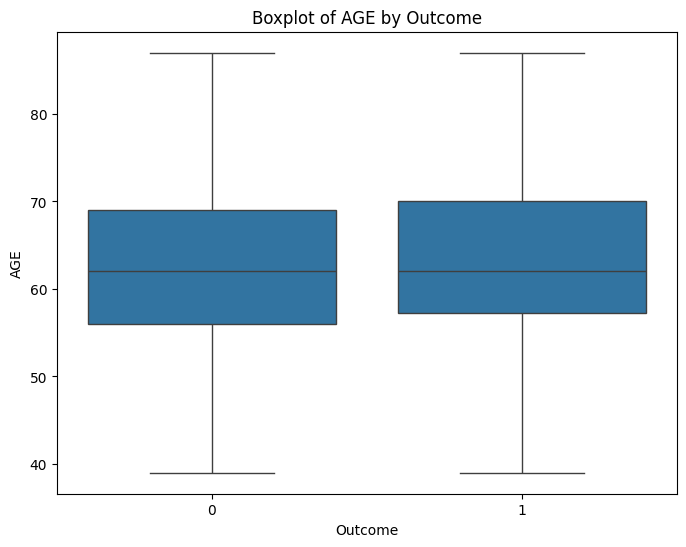

In [45]:
cols = [col for col in df.columns if col!="Outcome"]
for col in num_cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

### save the preprocessed dataset "Thoracic_processed.csv"

In [25]:
df.head()

,PRE4,PRE5,PRE7,PRE8,PRE9,PRE10,PRE11,PRE17,PRE19,PRE25,...,PRE14_OC14,PRE6_PRZ1,PRE6_PRZ2,DGN_DGN2,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,Outcome
0,2.88,2.16,0,0,0,1,1,0,0,0,...,1,1,0,1,0,0,0,0,0,0
1,3.40,1.88,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2.76,2.08,0,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
3,3.68,3.04,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2.44,0.96,0,1,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,0,1


In [26]:
df['Outcome'].value_counts()

Outcome
0    400
1     70
Name: count, dtype: int64

In [47]:
df.to_csv(path_or_buf="Thoracic_processed.csv")